In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

from train import get_config, main

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


# Loading

In [3]:
dataset = "set_game"
config_dataset = f"../configs/{dataset}.yaml"
config_model = "../configs/htrm_set_game.yaml"
config_train = "../configs/train_set_game.yaml"

config = get_config(config_train, config_model, config_dataset)

In [4]:
config['nray'] = 0
config['dl_train']['num_workers'] = 0
config['dl_val']['num_workers'] = 0
config['dl_test']['num_workers'] = 0


In [5]:
# mode = "test"
mode = "train"
trainer, model, ds, dls = main(config, mode=mode)

Global seed set to 123456


Generated dataset set_game with 0 examples, 
max nodes: 12, max edges: 10
Splits: train, val, test           with sizes: 0, 0, 0
Using BCE with logits loss (assumes logits output)


wandb: Currently logged in as: etienne-dreyer (etienne-dreyer-weizmann-institute-of-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING No relevant files were detected in the specified directory. No code will be logged to your run.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(


In [6]:
if mode == "train":
    trainer.fit(model, dls['train'], dls['val'])


  | Name | Type | Params
------------------------------
0 | net  | HTRM | 90.3 K
------------------------------
90.3 K    Trainable params
0         Non-trainable params
90.3 K    Total params
0.361     Total estimated model params size (MB)


Sanity Checking: 0it [00:00, ?it/s]

/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, val_dataloader 0, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Users/ets/miniconda3/envs/torchmetal/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:224: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 8 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(


Training: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.


In [7]:
# Check config batch limits
print(f"limit_train_batches: {config.get('limit_train_batches')}")
print(f"limit_val_batches: {config.get('limit_val_batches')}")
print(f"num_epochs: {config.get('num_epochs')}")


limit_train_batches: 100
limit_val_batches: 20
num_epochs: 20


In [8]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if im.dtype == torch.bool:
        im = im.float()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1, interpolation='nearest', aspect='equal')
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

In [9]:
for example in ds.dataset:
    node_feats, im = example
    break

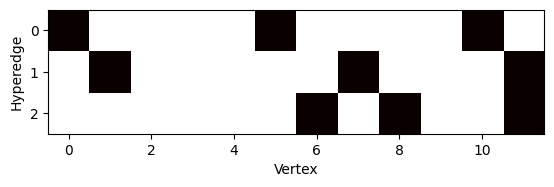

In [10]:
plot_incidence_matrix(im)

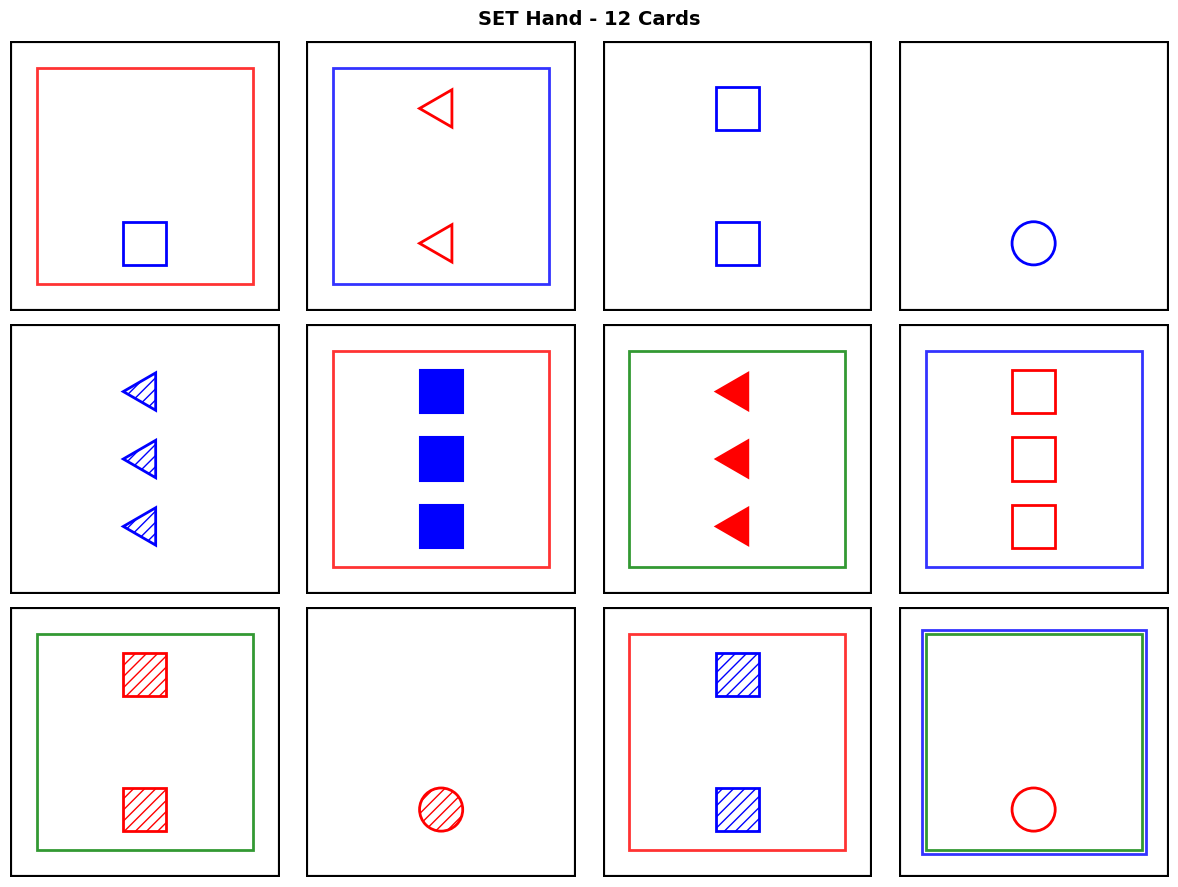

In [11]:
# Reload the updated visualization function
from utils.set_game_data import VisualizeSetHandV2

# Test with incidence matrix showing set memberships
VisualizeSetHandV2(node_feats.numpy(), im)
